# How to add coordinates to an `xarray.DataArray` or `xarray.DataSet`

## Problem

This guide shows you how to add projected coordinates to an `xarray.Dataset` or `xarray.DataArray`.

Many geospatial data granules already have _coordinates variables_ defined.  These _coordinate variables_ are automatically associated with `DataArrays` or `Dataset` objects.  Unfortunately, some data granules do not.  This makes operations such as coordinate transformations and spatial subsetting difficult.  In this How-To Guide, we show where to find information about _coordinate systems_ and how to use this information with the Python `affine` package to generate coordinates and add those coordinates to an `xarray.DataArray` or `xarray.Dataset`.

If you want to learn more about geospatial coordinates see the [Coordinate Tutorial]() or the [Coordinate Learning Guide]().

## Solution

In [22]:
import xarray as xr
import numpy as np
from affine import Affine

We'll use a version of the NSIDC Polar Stereographic Sea Ice Concentration (NSIDC0081), that has the coordinate variables removed, as an example data granule. 

In [6]:
ds = xr.open_dataset("../example_data/NSIDC0081_SEAICE_PS_N25km_20230627_v2.0.nc",
                     drop_variables=["time","x","y","crs","F16_ICECON","F17_ICECON"])  # Will create a separate dataset
ds

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 1, y: 448, x: 304)
Dimensions without coordinates: time, y, x
Data variables:
    F18_ICECON  (time, y, x) float64 1MB ...
Attributes: (12/49)
    title:                     Near-Real-Time DMSP SSMIS Daily Polar Gridded ...
    summary:                   This data set provides a Near-Real-Time (NRT) ...
    id:                        10.5067/YTTHO2FJQ97K
    license:                   Access Constraint: These data are freely, open...
    acknowledgment:            These data are produced and supported by the N...
    metadata_link:             https://doi.org/10.5067/YTTHO2FJQ97K
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    product_version:           v2.0
    source:                    NOAA Comprehensive Large Array-data Stewardshi...
    instrument:                SSMIS > Special Sensor Microwave Imager/Sounde...
    platform:                  DMSP 5D-3/F16 > Defense Meteorological Satelli...

We can see from the dataset readout that the `F18_ICECON` variable has dimensions `time`, `x`, and `y` of length 1, 448 and 304 respectively.  Each of these dimensions should have an associated 1-dimensional _coordinate variable_.

Plotting `F17_ICECON` shows that x and y axes are column and row indices of the grid, and that the data are plotted upside down with respect to the Browse image in Figure 1 of the [Dataset User Guide](https://nsidc.org/sites/default/files/documents/user-guide/nsidc-0081-v002-userguide.pdf).

Data plotting "upside down" is often because there are no _projected coordinate_ variables and the origin of the image coordinate system is in the upper-left corner of the image. 

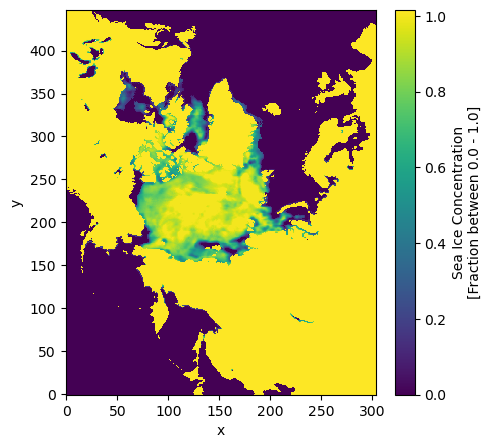

In [12]:
ds.F18_ICECON.plot(aspect='equal', figsize=(5,5))  # aspect and figsize both need to be defined for the correct aspect ratio 

To define the `x` and `y` coordinates, we need the _width_ and _height_ of grid cells, and the `x` and `y` coordinates of the upper-left corner of the upper-left grid cell of the image.  This information (or at least most of it) is in the User Guide and on the [A Guide to NSIDC's Polar Stereographic Projection](https://nsidc.org/data/user-resources/help-center/guide-nsidcs-polar-stereographic-projection) page under the [Grid Dimensions](https://nsidc.org/data/user-resources/help-center/guide-nsidcs-polar-stereographic-projection#anchor-grid-dimensions) and [Grid Coordinates](https://nsidc.org/data/user-resources/help-center/guide-nsidcs-polar-stereographic-projection#anchor-grid-coordinates) tables.

_Add list of grids to reference section_

Using these resources we that grid cell width and height is 25 km, and the `x` coordinate of the upper-left corner of the upper left pixel is -3850 km and the `y` coordinate of the upper left corner of the upper-left grid cell is 4350 km.

We'll define an [Affine matrix](https://en.wikipedia.org/wiki/Affine_transformation) using the `affine` Python package that we can use to generate coordinates.  

By convention, projected spatial coordinates are in meters.

In [13]:
cell_width = 25000.
cell_height = -25000.
upper_left_x = -3850000.
upper_left_y = 4350000.

You will notice that `cell_height` is `-25000` instead of `25000`.  This is to account for the origin of the image coordinates being in the upper-left corner. 

We can now define the Affine transform.

In [19]:
transform = Affine.from_gdal(upper_left_x, cell_width, 0, upper_left_y, 0, cell_height)
transform

Affine(25000.0, 0.0, -3850000.0,
       0.0, -25000.0, 4350000.0)

We can check that the transform is correct by getting the projected coordinates of the upper-left corner of the data grid.  In _image coordinates_, this is point (0,0).  This should give `(-3850000., 4350000.)`.

We could also check for the other corners using the data in the [Grid Coordinates table](https://nsidc.org/data/user-resources/help-center/guide-nsidcs-polar-stereographic-projection#anchor-grid-coordinates).

In [20]:
assert transform * (0,0) == (-3850000., 4350000.)

To define the `x` and `y` coordinates of the data, we want the coordinates for the center of each cell.  We can use `numpy` to generate _image coordinates_ of grid cell centers.

In [26]:
cols = np.arange(0.5, ds.sizes['x'], 1)
rows = np.arange(0.5, ds.sizes['y'], 1)

x, _ = transform * (cols, 0)
_, y = transform * (0, rows)

In [28]:
ds['x'] = x
ds['y'] = y
ds

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 1, y: 448, x: 304)
Coordinates:
  * y           (y) float64 4kB 4.338e+06 4.312e+06 ... -6.812e+06 -6.838e+06
  * x           (x) float64 2kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
Dimensions without coordinates: time
Data variables:
    F18_ICECON  (time, y, x) float64 1MB ...
Attributes: (12/49)
    title:                     Near-Real-Time DMSP SSMIS Daily Polar Gridded ...
    summary:                   This data set provides a Near-Real-Time (NRT) ...
    id:                        10.5067/YTTHO2FJQ97K
    license:                   Access Constraint: These data are freely, open...
    acknowledgment:            These data are produced and supported by the N...
    metadata_link:             https://doi.org/10.5067/YTTHO2FJQ97K
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    product_version:           v2.0
    source:                    NOAA Comprehensive Large Array-data Stewardshi...
    instrument:                SSMIS > Special Sensor Microwave Imager/Sounde...
    platform:                  DMSP 5D-3/F16 > Defense Meteorological Satelli...

This is sufficient if you just want projected coordinates for plotting or subsetting.  But it is good practice to add attributes to coordinates variables to describe the units, a long name, and a standard name for each coordinate.  This follows CF-Conventions and increases interoperability of the data.

In [30]:
ds.x.attrs = {
    "units": "m",
    "long_name": "x coordinate of projection",
    "standard_name": "projection_x_coordinate",
}

ds.y.attrs = {
    "units": "m",
    "long_name": "y coordinate of projection",
    "standard_name": "projection_y_coordinate",
}

Now plotting the `F17_ICECON`, produces a plot that is the correct way up and has `x` and `y` coordinates in meters.

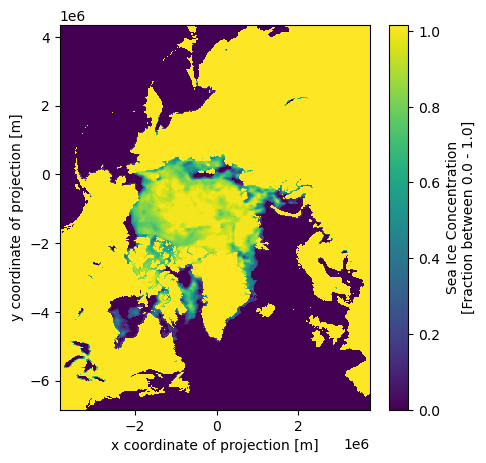

In [31]:
ds.F18_ICECON.plot(aspect='equal', figsize=(5,5))

The data are still missing a _Coordinate Reference System_ (CRS).  We describe how to add a CRS to a dataset in [How to add a CRS to an xarray.Dataset](TBD)